<a href="https://colab.research.google.com/github/Yuvraj6085/cnnpro/blob/main/DCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#  52854155-0c17c21638c360c3d41a4aab2
# url=f"https://pixabay.com/api/?key

In [2]:
import os
import requests
from PIL import Image
from io import BytesIO

In [3]:
API_KEY="52854155-0c17c21638c360c3d41a4aab2"

In [4]:
def download_images(query, count=100, save_dir='dataset'):
    url = f"https://pixabay.com/api/?key={API_KEY}&q={query}&image_type=photo&per_page={count}"
    response = requests.get(url)
    data = response.json()
    class_dir = os.path.join(save_dir, query)
    os.makedirs(class_dir, exist_ok=True)
    for i, hit in enumerate(data['hits']):
        image_url = hit['webformatURL']
        img_data = requests.get(image_url).content
        with open(os.path.join(class_dir, f"{query}_{i}.jpg"), 'wb') as f:
            f.write(img_data)

    print(f" Downloaded {len(data['hits'])} images for '{query}'")

download_images("dog")
download_images("cat")

 Downloaded 100 images for 'dog'
 Downloaded 100 images for 'cat'


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt


In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [20]:
train_generator = train_datagen.flow_from_directory(
    'dataset',                 # Dataset path
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 160 images belonging to 2 classes.


In [21]:
validation_generator = train_datagen.flow_from_directory(
    'dataset',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 40 images belonging to 2 classes.


In [22]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3),
           kernel_regularizer=regularizers.l2(0.001)),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary output: dog or cat
])

In [23]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_dog_cat_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)


In [25]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5395 - loss: 1.9346
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_dog_cat_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5402 - loss: 1.9178 - val_accuracy: 0.5000 - val_loss: 1.0536
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5144 - loss: 1.0518
Epoch 2: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5109 - loss: 1.0515 - val_accuracy: 0.5000 - val_loss: 1.0370
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5643 - loss: 1.0360
Epoch 3: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5546 - loss: 1.0359 - val_accuracy: 0.5000 - val_loss: 1.0247
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4812 - loss: 1.0235
Epoch 4: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4792 - loss: 1.0230 - val_accuracy: 0.5000 - val_loss: 1.0129
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4847 - loss: 1.0112
Epoch 5: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6112 - loss: 0.8308 - val_accuracy: 0.5750 - val_loss: 0.8285
Epoch 28/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4492 - loss: 0.8278
Epoch 28: val_accuracy did not improve from 0.57500
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4535 - loss: 0.8277 - val_accuracy: 0.4000 - val_loss: 0.8250
Epoch 29/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - accuracy: 0.5276 - loss: 0.8236
Epoch 29: val_accuracy did not improve from 0.57500
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5230 - loss: 0.8236 - val_accuracy: 0.4250 - val_loss: 0.8216
Epoch 30/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5908 - loss: 0.8191
Epoch 30: val_accuracy did not improve from 0.57500
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5767 - loss: 0.8192 - val_accuracy: 0.5000 - val_loss: 0.8185


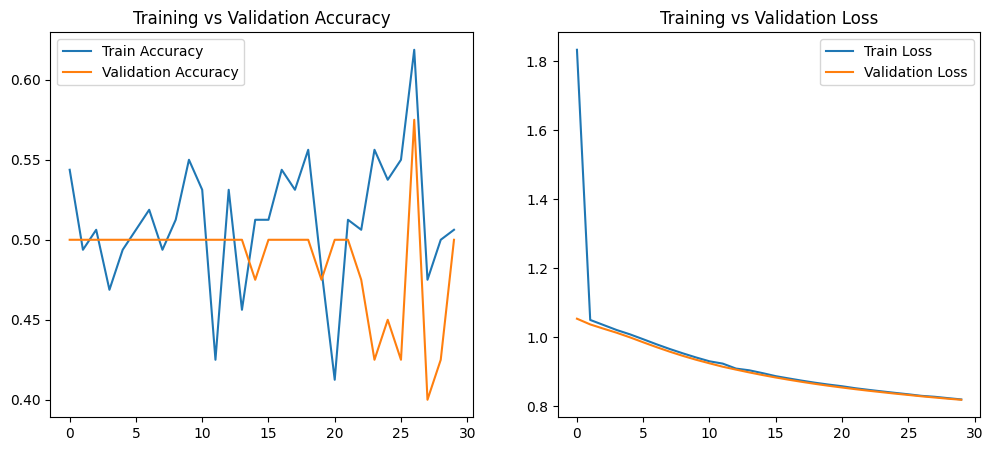

In [26]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [27]:
model.save("dog_cat_dcnn_model.h5")
print("Final model saved successfully as 'dog_cat_dcnn_model.h5'")

Final model saved successfully as 'dog_cat_dcnn_model.h5'


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


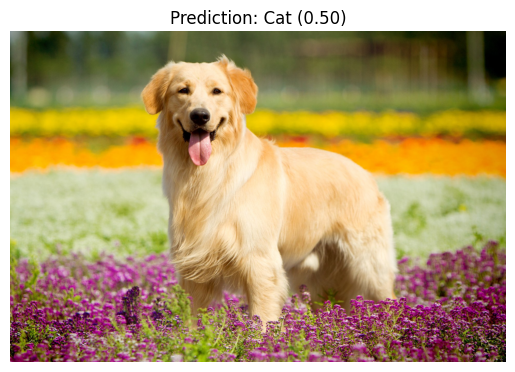

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


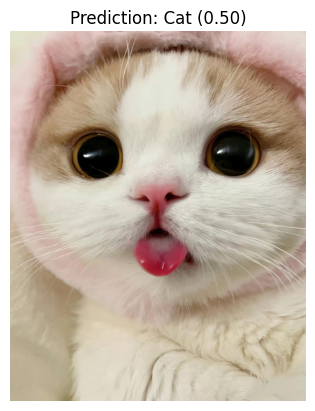

In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array)[0][0]
    label = " Dog" if prediction > 0.5 else "Cat"

    plt.imshow(image.load_img(img_path))
    plt.title(f"Prediction: {label} ({prediction:.2f})")
    plt.axis("off")
    plt.show()

# Example Test
predict_image("/content/a1.jpg")
predict_image("/content/a2.jpg")